# Experiment 9 - CLAHE HSV + Gaussian Filter

**Pipeline preprocessing:** CLAHE pada channel S dan V di ruang warna HSV (meningkatkan kontras saturasi dan kecerahan tanpa mengubah hue), diikuti Gaussian filter untuk meredam noise. Hasil dikembalikan ke BGR kemudian dikonversi ke grayscale sebelum ekstraksi fitur GLCM.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull

    %cd {REPO_DIR}/notebooks

    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'

    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *


EXPERIMENT_NAME = "experiment9"


CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
# Muat gambar warna (color=True) agar preprocessing HSV bisa dilakukan
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256), color=True)
print(f"Dataset loaded: {len(images)} gambar warna, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]

Loading cumulus:   1%|          | 7/775 [00:00<00:11, 65.52it/s]

Loading cumulus:   2%|▏         | 16/775 [00:00<00:10, 74.31it/s]

Loading cumulus:   3%|▎         | 25/775 [00:00<00:09, 77.14it/s]

...

Loading mixed:  93%|█████████▎| 566/607 [00:05<00:00, 101.08it/s]

Loading mixed:  95%|█████████▌| 577/607 [00:05<00:00, 98.37it/s] 

Loading mixed:  97%|█████████▋| 587/607 [00:05<00:00, 97.37it/s]

Loading mixed:  99%|█████████▊| 598/607 [00:05<00:00, 100.57it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(128, 128)
Dataset loaded: 19000 gambar warna, 7 kelas


## Dataset Visualization & Distribution

In [ ]:
# Tampilkan contoh gambar untuk setiap kelas
unique_labels = sorted(list(set(labels)))
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(labels == label)[0][0]
    img = images[idx]
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    else:
        axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Tampilkan bar chart distribusi kelas
plt.figure(figsize=(10, 4))
label_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')
plt.title('Distribusi Jumlah Data Per Kelas Awan')
plt.xlabel('Kelas Awan')
plt.ylabel('Jumlah Gambar')
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Preprocessing Pipeline

In [4]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# ================================================================
PIPELINE = [
    lambda img: clahe_hsv(img, tile_size=8, clip_limit=2.0),
    lambda img: gaussian_filter(img, kernel_size=5, sigma=1.0),
]


def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image

In [5]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

if not PIPELINE:
    images_preprocessed_color = images.copy()
else:
    # Preallocate output array to prevent MemoryError (OOM)
    images_preprocessed_color = np.empty((len(images), images.shape[1], images.shape[2], 3), dtype=np.uint8)
    if USING_GPU:
        print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
        with ThreadPoolExecutor(max_workers=4) as executor:
            for idx, res in enumerate(tqdm(
                executor.map(process_one, images),
                total=len(images),
                desc="Preprocessing"
            )):
                images_preprocessed_color[idx] = res
    else:
        print("Menggunakan Pemrosesan Sekuensial CPU...")
        for idx in tqdm(range(len(images)), desc="Preprocessing"):
            images_preprocessed_color[idx] = process_one(images[idx])

Menggunakan Pemrosesan Sekuensial CPU...


Preprocessing:   0%|          | 0/19000 [00:00<?, ?it/s]

Preprocessing:   0%|          | 2/19000 [00:00<19:48, 15.98it/s]

Preprocessing:   0%|          | 5/19000 [00:00<14:02, 22.54it/s]

Preprocessing:   0%|          | 9/19000 [00:00<12:09, 26.05it/s]

...

Preprocessing: 100%|█████████▉| 18987/19000 [09:29<00:00, 34.86it/s]

Preprocessing: 100%|█████████▉| 18991/19000 [09:29<00:00, 34.15it/s]

Preprocessing: 100%|█████████▉| 18995/19000 [09:29<00:00, 34.66it/s]

Preprocessing: 100%|█████████▉| 18999/19000 [09:29<00:00, 33.44it/s]

Preprocessing: 100%|██████████| 19000/19000 [09:29<00:00, 33.34it/s]

## Visualisasi Preprocessing

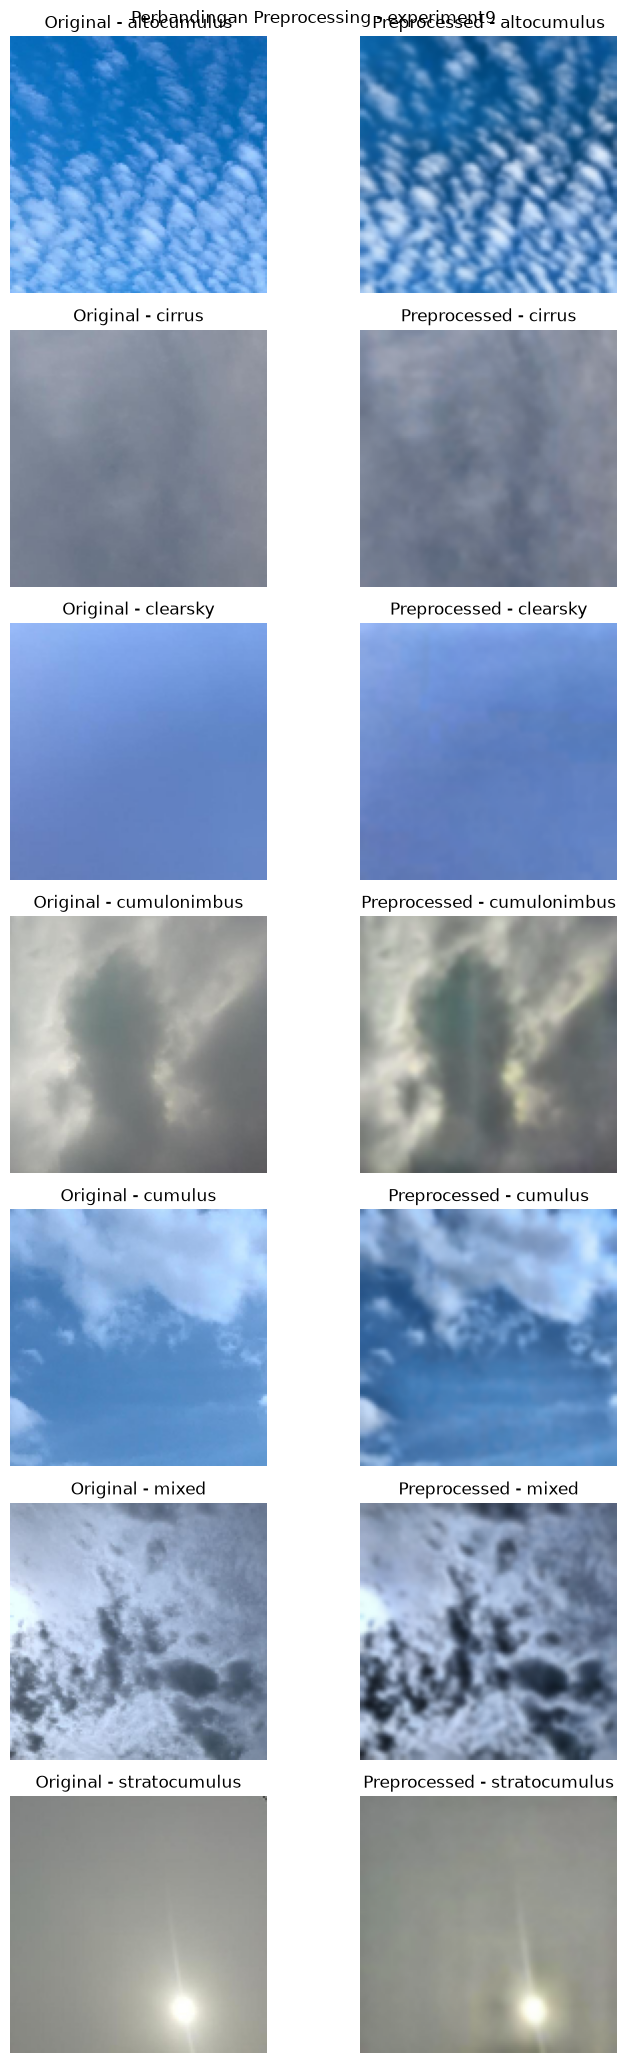

In [6]:
unique_labels = sorted(set(labels))
n_classes = len(unique_labels)
fig, axes = plt.subplots(n_classes, 2, figsize=(8, 3 * n_classes))
if n_classes == 1:
    axes = np.array([axes])

for row, label in enumerate(unique_labels):
    idx = next(i for i, lb in enumerate(labels) if lb == label)

    axes[row, 0].imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'Original - {label}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cv2.cvtColor(images_preprocessed_color[idx], cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f'Preprocessed - {label}')
    axes[row, 1].axis('off')

plt.suptitle(f'Perbandingan Preprocessing - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

# Free original images to save RAM
del images
import gc
gc.collect()

## Konversi ke Grayscale

In [7]:
# Konversi hasil preprocessing (BGR) ke grayscale untuk ekstraksi GLCM
images_preprocessed = np.empty((len(images_preprocessed_color), 256, 256), dtype=np.uint8)
for i in tqdm(range(len(images_preprocessed_color)), desc="Converting to grayscale"):
    images_preprocessed[i] = cv2.cvtColor(images_preprocessed_color[i], cv2.COLOR_BGR2GRAY)

# Free color preprocessed images to save memory
del images_preprocessed_color
import gc
gc.collect()

Converting to grayscale:   0%|          | 0/19000 [00:00<?, ?it/s]

Converting to grayscale:  23%|██▎       | 4285/19000 [00:00<00:00, 42843.30it/s]

Converting to grayscale:  46%|████▌     | 8684/19000 [00:00<00:00, 43516.35it/s]

Converting to grayscale:  69%|██████▊   | 13036/19000 [00:00<00:00, 42242.08it/s]

Converting to grayscale:  91%|█████████▏| 17344/19000 [00:00<00:00, 42561.87it/s]

Converting to grayscale: 100%|██████████| 19000/19000 [00:00<00:00, 42575.51it/s]

## Feature Extraction (GLCM)

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [9]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)

    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))

    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))

    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))

    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))

    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))

    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))

    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

dataTable = {
    'Filename': filenames,
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur tersimpan ke {csv_path}')
df.head()

Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]

Extracting GLCM features:   0%|          | 7/19000 [00:00<04:57, 63.76it/s]

Extracting GLCM features:   0%|          | 14/19000 [00:00<04:49, 65.67it/s]

Extracting GLCM features:   0%|          | 22/19000 [00:00<04:38, 68.02it/s]

Extracting GLCM features:   0%|          | 29/19000 [00:00<04:39, 67.81it/s]

...

Extracting GLCM features: 100%|█████████▉| 18993/19000 [04:25<00:00, 65.59it/s]

Extracting GLCM features: 100%|██████████| 19000/19000 [04:25<00:00, 66.28it/s]

Extracting GLCM features: 100%|██████████| 19000/19000 [04:25<00:00, 71.64it/s]

Fitur tersimpan ke hasil_ekstraksi_experiment9.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1_cumulus_000001.jpg,cumulus,20.024483,34.709777,26.532173,54.849774,0.399823,0.278807,0.312140,0.259246,...,0.000896,0.000762,0.036756,0.028038,0.029941,0.027609,0.990478,0.983500,0.987410,0.973927
1,1_cumulus_000002.jpg,cumulus,13.600455,33.478951,23.442052,39.310311,0.425019,0.313897,0.364605,0.306460,...,0.001489,0.001203,0.042162,0.034832,0.038592,0.034684,0.996458,0.991305,0.993901,0.989791
2,1_cumulus_000003.jpg,cumulus,40.973856,86.099200,44.043369,80.258913,0.316019,0.255619,0.310274,0.242469,...,0.000939,0.000699,0.030677,0.026910,0.030635,0.026432,0.991195,0.981407,0.990475,0.982665
3,1_cumulus_000004.jpg,cumulus,27.616634,54.964164,32.279097,61.800670,0.408972,0.312067,0.360827,0.302362,...,0.001296,0.000989,0.038267,0.032844,0.036001,0.031450,0.993961,0.987985,0.992951,0.986491
4,1_cumulus_000005.jpg,cumulus,16.218565,51.254325,40.939715,60.980408,0.417910,0.248738,0.287768,0.259827,...,0.000646,0.000563,0.031881,0.023799,0.025407,0.023718,0.996793,0.989867,0.991913,0.987943


## Feature Selection

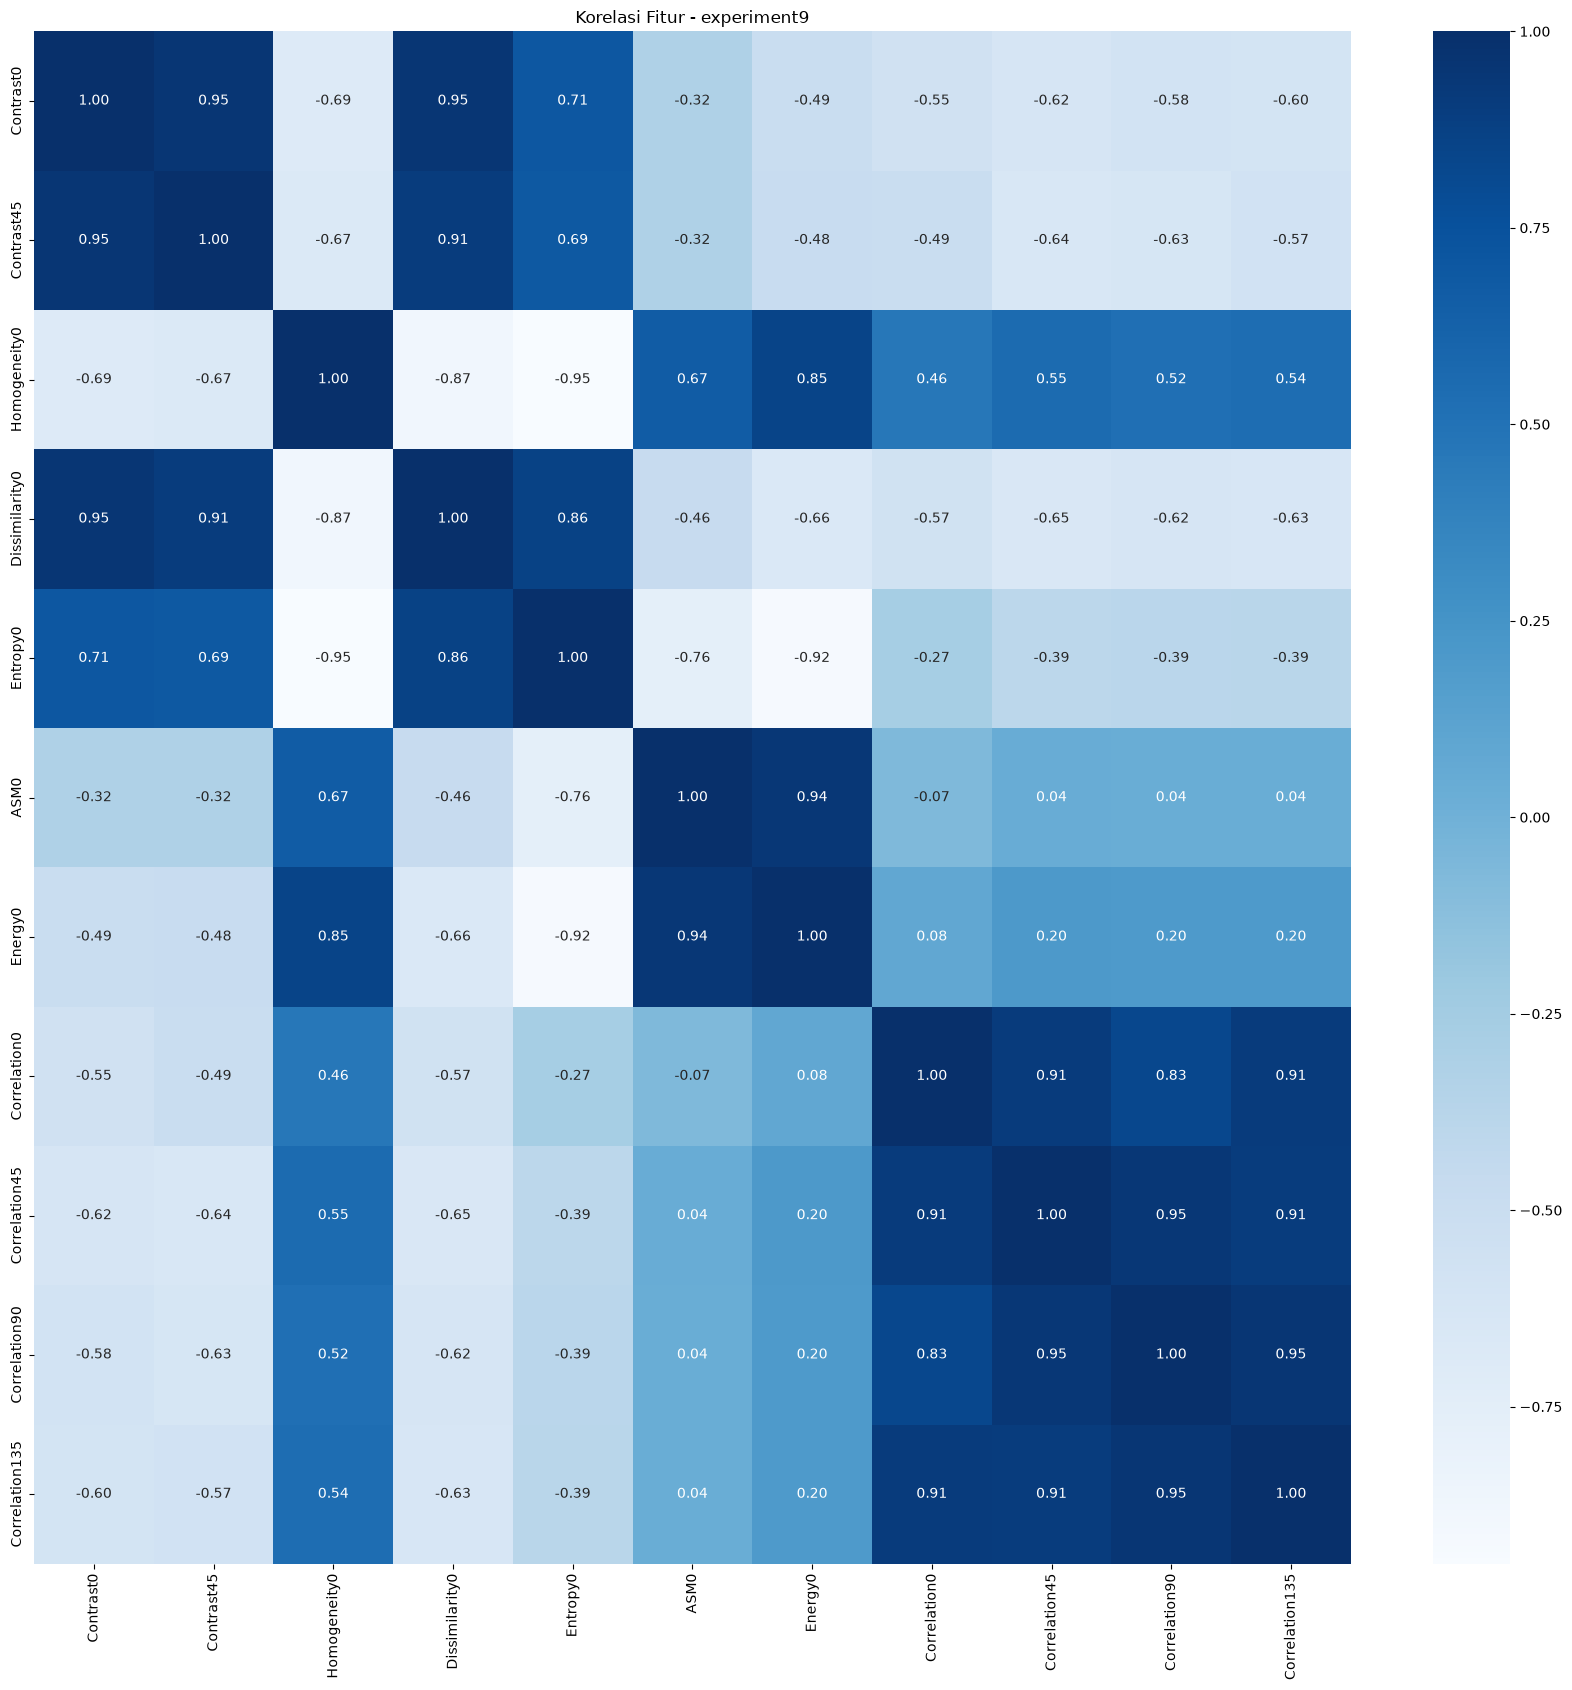

,Contrast0,Contrast45,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90,Correlation135
0,20.024483,34.709777,0.399823,2.812746,7.330740,0.001351,0.036756,0.990478,0.983500,0.987410,0.973927
1,13.600455,33.478951,0.425019,2.353531,7.163019,0.001778,0.042162,0.996458,0.991305,0.993901,0.989791
2,40.973856,86.099200,0.316019,4.073880,7.772377,0.000941,0.030677,0.991195,0.981407,0.990475,0.982665
3,27.616634,54.964164,0.408972,3.053519,7.422750,0.001464,0.038267,0.993961,0.987985,0.992951,0.986491
4,16.218565,51.254325,0.417910,2.526759,7.515171,0.001016,0.031881,0.996793,0.989867,0.991913,0.987943
...,...,...,...,...,...,...,...,...,...,...,...
18995,14.318713,39.604315,0.440985,2.319328,7.110730,0.001475,0.038403,0.992477,0.979139,0.988743,0.984572
18996,25.712106,35.439023,0.282573,3.532726,7.666362,0.000702,0.026504,0.988592,0.984236,0.990209,0.974738
18997,15.533834,56.801910,0.329003,2.778789,7.658726,0.000673,0.025945,0.995574,0.983872,0.987789,0.983581
18998,19.865834,81.805196,0.339315,2.990219,7.584649,0.000873,0.029539,0.993843,0.974607,0.977310,0.968945


In [10]:
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

x_new

## Splitting Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(15200, 11)
(3800, 11)


## Feature Normalization

In [12]:
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

## Modeling

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [14]:
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       1.00      1.00      1.00      1525
     clearsky       1.00      1.00      1.00      2991
 cumulonimbus       1.00      1.00      1.00      4611
      cumulus       1.00      1.00      1.00      1220
        mixed       1.00      1.00      1.00       764
stratocumulus       1.00      1.00      1.00      2909

     accuracy                           1.00     15200
    macro avg       1.00      1.00      1.00     15200
 weighted avg       1.00      1.00      1.00     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2991    0    0    0    0]
 [   0    0    0 4611    0    0    0]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    0    0    0    0 2909]]
Accuracy: 1.0

------Random Forest - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.67      0.63      0.65       295
       cirrus       0.45      0.28      0.34       381
     clearsky       0.62      0.70      0.66       748
 cumulonimbus       0.57      0.72      0.63      1153
      cumulus       0.73      0.73      0.73       305
        mixed       0.48      0.29      0.36       191
stratocumulus       0.47      0.37      0.41       727

     accuracy                           0.58      3800
    macro avg       0.57      0.53      0.54      3800
 weighted avg       0.56      0.58      0.56      3800

[[185  16   1  60  15  14   4]
 [ 25 106  14 160  26  15  35]
 [  1   9 523  71   1   0 143]
 [ 16  53 104 825  22  10 123]
 [ 11  18   2  30 224  20   0]
 [ 30  23   0  58  20  55   5]
 [  7  12 194 243   0   1 270]]
Accuracy: 0.5757894736842105

------SVM - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.74      0.68      0.71      1180
       cirrus       0.55      0.11      0.19      1525
     clearsky       0.57      0.75      0.65      2991
 cumulonimbus       0.55      0.74      0.63      4611
      cumulus       0.78      0.76      0.77      1220
        mixed       0.51      0.27      0.35       764
stratocumulus       0.46      0.31      0.37      2909

     accuracy                           0.57     15200
    macro avg       0.59      0.52      0.52     15200
 weighted avg       0.57      0.57      0.54     15200

[[ 807   20    4  254   39   55    1]
 [  72  171  116  951   61   51  103]
 [   0    6 2255  233    1    0  496]
 [  40   27  574 3419   62   39  450]
 [  44   31    2  162  926   54    1]
 [ 120   39    7  288   97  207    6]
 [  13   17 1021  964    0    0  894]]
Accuracy: 0.5709868421052632

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.71      0.60      0.65       295
       cirrus       0.41      0.09      0.15       381
     clearsky       0.57      0.75      0.65       748
 cumulonimbus       0.54      0.76      0.63      1153
      cumulus       0.75      0.72      0.73       305
        mixed       0.51      0.26      0.34       191
stratocumulus       0.47      0.31      0.38       727

     accuracy                           0.56      3800
    macro avg       0.56      0.50      0.50      3800
 weighted avg       0.55      0.56      0.53      3800

[[178  10   2  74  15  15   1]
 [ 22  34  27 241  21  12  24]
 [  4   2 561  59   1   0 121]
 [  6   9 138 872  20   9  99]
 [ 12  10   0  50 220  12   1]
 [ 28  17   1  74  18  49   4]
 [  2   1 262 236   0   0 226]]
Accuracy: 0.5631578947368421

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.72      0.77      0.74      1180
       cirrus       0.56      0.44      0.49      1525
     clearsky       0.66      0.83      0.74      2991
 cumulonimbus       0.66      0.76      0.71      4611
      cumulus       0.81      0.78      0.79      1220
        mixed       0.61      0.36      0.45       764
stratocumulus       0.65      0.46      0.54      2909

     accuracy                           0.67     15200
    macro avg       0.67      0.63      0.64     15200
 weighted avg       0.66      0.67      0.66     15200

[[ 905   34    3  132   38   54   14]
 [  83  669   97  490   47   37  102]
 [   0   37 2468  183    0    1  302]
 [  72  189  448 3527   55   34  286]
 [  50   75    2  100  951   39    3]
 [ 123   82    9  176   85  274   15]
 [  32  110  687  740    1    7 1332]]
Accuracy: 0.6661842105263158

------KNN - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.58      0.61      0.59       295
       cirrus       0.34      0.25      0.28       381
     clearsky       0.54      0.69      0.61       748
 cumulonimbus       0.54      0.65      0.59      1153
      cumulus       0.75      0.70      0.72       305
        mixed       0.42      0.23      0.30       191
stratocumulus       0.40      0.26      0.32       727

     accuracy                           0.52      3800
    macro avg       0.51      0.48      0.49      3800
 weighted avg       0.51      0.52      0.51      3800

[[180  17   1  58  15  18   6]
 [ 33  94  24 165  21  16  28]
 [  0  16 516  85   1   1 129]
 [ 37  80 146 751  13   9 117]
 [ 18  17   1  39 212  17   1]
 [ 38  24   3  60  19  44   3]
 [  6  32 259 240   0   1 189]]
Accuracy: 0.5226315789473684


## Evaluation - Confusion Matrix

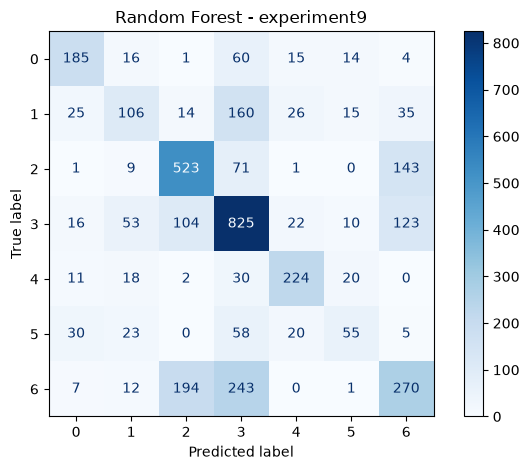

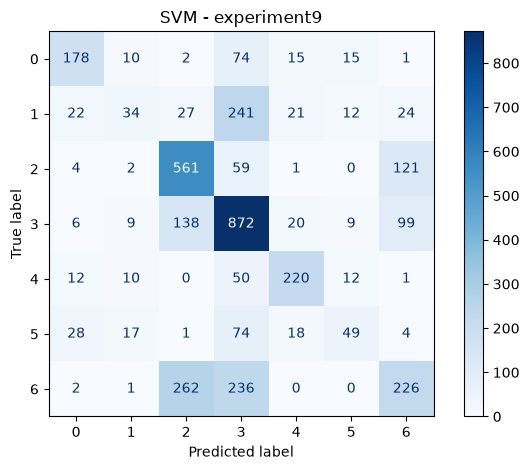

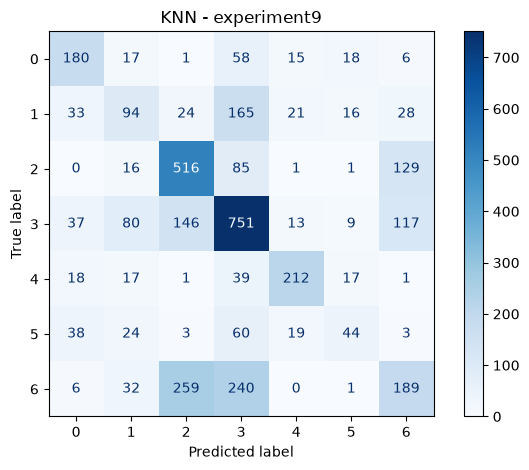

In [15]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)

In [16]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (30 baris total)


README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,baseline,rf,0.557895,0.550267,0.557895,0.549278
1,baseline,svm,0.524211,0.519361,0.524211,0.500611
2,baseline,knn,0.512895,0.503749,0.512895,0.502514
3,experiment1,rf,0.545526,0.529528,0.545526,0.524138
4,experiment1,svm,0.530526,0.506792,0.530526,0.469833
5,experiment1,knn,0.492368,0.469816,0.492368,0.472107
6,experiment2,rf,0.592368,0.578947,0.592368,0.580687
7,experiment2,svm,0.584474,0.566006,0.584474,0.555292
8,experiment2,knn,0.551053,0.536193,0.551053,0.538876
9,experiment3,rf,0.578947,0.565558,0.578947,0.565837


## Analisis

> **[ISI ANALISIS DI SINI]**
> Jelaskan:
> - Pengaruh CLAHE pada ruang warna HSV terhadap fitur GLCM
> - Perbandingan performa dengan Experiment 1-4 (preprocessing grayscale biasa)
> - Apakah preprocessing di ruang HSV memberikan keuntungan dibanding preprocessing langsung di grayscale
> - Kelas mana yang paling sulit diklasifikasikan dan mengapa